In [1]:
!pip uninstall -y protobuf
!pip install protobuf==3.20.3


Found existing installation: protobuf 5.29.5
Uninstalling protobuf-5.29.5:
  Successfully uninstalled protobuf-5.29.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.8 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight


2025-12-27 15:44:54.979302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766850295.458641      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766850295.575541      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766850296.700551      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766850296.700594      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766850296.700597      55 computation_placer.cc:177] computation placer alr

In [3]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/kaggle/input/processed-dip/processed/train"
val_dir = "/kaggle/input/processed-dip/processed/val"
test_dir = "/kaggle/input/processed-dip/processed/test"


In [92]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

# 2. Đưa về chuẩn [0, 1] như bạn muốn
normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))
test_ds = test_ds.map(lambda x, y: (normalization(x), y))

# 3. Tối ưu hiệu năng
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 17745 files belonging to 2 classes.
Found 597 files belonging to 2 classes.
Found 575 files belonging to 2 classes.


In [5]:
y_train = np.concatenate([y.numpy() for _, y in train_ds.unbatch()])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = {
    0: class_weights[0],
    1: class_weights[1]
}


In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


In [7]:
cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(), # Output: 112x112

    # Block 2
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(), # Output: 56x56

    # Block 3
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(), # Output: 28x28
    
    # Block 4 (THÊM MỚI)
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(), # Output: 14x14
    
    # Block 5 (THÊM MỚI - Tùy chọn)
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(), # Output: 7x7

    # Lúc này Feature map nhỏ (7x7), dùng GAP mới hiệu quả
    layers.GlobalAveragePooling2D(), 
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [8]:
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation, # Dùng lại layer augmentation cũ
        
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)), # 112x112
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)), # 56x56
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)), # 28x28
        
        # Block 4 (Thêm để học chi tiết hơn)
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)), # 14x14
        
        # Block 5 (Xuống size nhỏ nhất)
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)), # 7x7
        
        # Lúc này feature map nhỏ, dùng GAP mới hiệu quả
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid') # Binary classification
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(), Recall()]
    )
    return model

# Khởi tạo và train lại
cnn_model = build_cnn()
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, # Tăng epoch lên chút vì model sâu hơn
    class_weight=class_weight
)

Epoch 1/10


I0000 00:00:1766850399.242044     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


555/555 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.6371 - loss: 0.5859 - precision: 0.7766 - recall: 0.4907 - val_accuracy: 0.6717 - val_loss: 0.6331 - val_precision: 0.9880 - val_recall: 0.5604
Epoch 2/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 33s 59ms/step - accuracy: 0.8408 - loss: 0.3728 - precision: 0.8916 - recall: 0.8223 - val_accuracy: 0.6516 - val_loss: 0.7125 - val_precision: 0.9957 - val_recall: 0.5285
Epoch 3/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.8760 - loss: 0.2994 - precision: 0.9158 - recall: 0.8631 - val_accuracy: 0.8208 - val_loss: 0.3838 - val_precision: 0.9882 - val_recall: 0.7654
Epoch 4/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.8949 - loss: 0.2557 - precision: 0.9294 - recall: 0.8839 - val_accuracy: 0.8559 - val_loss: 0.2997 - val_precision: 0.9889 - val_recall: 0.8132
Epoch 5/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9005 - loss: 0.2392 - precision: 0.9339 - recall: 0.8895 - val_accuracy: 0.8007 - val_loss: 0.4

In [9]:
cnn_model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)


In [10]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weight
)


Epoch 1/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.9261 - loss: 0.1894 - precision_1: 0.9495 - recall_1: 0.9201 - val_accuracy: 0.9028 - val_loss: 0.2252 - val_precision_1: 0.9872 - val_recall_1: 0.8793
Epoch 2/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9288 - loss: 0.1764 - precision_1: 0.9513 - recall_1: 0.9232 - val_accuracy: 0.8811 - val_loss: 0.2654 - val_precision_1: 0.9894 - val_recall_1: 0.8474
Epoch 3/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9301 - loss: 0.1756 - precision_1: 0.9534 - recall_1: 0.9232 - val_accuracy: 0.9112 - val_loss: 0.2044 - val_precision_1: 0.9898 - val_recall_1: 0.8884
Epoch 4/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9337 - loss: 0.1650 - precision_1: 0.9558 - recall_1: 0.9273 - val_accuracy: 0.9179 - val_loss: 0.1962 - val_precision_1: 0.9899 - val_recall_1: 0.8975
Epoch 5/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9366 - loss: 0.1570 - precision_1: 0.9557 - recall_1: 0.9

In [11]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_prob_cnn = cnn_model.predict(test_ds)
y_pred_cnn = (y_pred_prob_cnn > 0.3).astype(int).ravel()

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
cm_cnn


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


array([[149,   9],
       [ 16, 401]])

In [12]:
print(classification_report(
    y_true,
    y_pred_cnn,
    target_names=['NORMAL', 'PNEUMONIA']
))


              precision    recall  f1-score   support

      NORMAL       0.90      0.94      0.92       158
   PNEUMONIA       0.98      0.96      0.97       417

    accuracy                           0.96       575
   macro avg       0.94      0.95      0.95       575
weighted avg       0.96      0.96      0.96       575



In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False # Đóng băng

# Tạo Model mới
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)

x = layers.Rescaling(scale=2.0, offset=-1.0)(x)
# -----------------------------------------

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

mbv2_model = models.Model(inputs, outputs)

# Compile lại
mbv2_model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Train lại nhanh (vì chỉ train lớp Dense mới)
history_mbv2 = mbv2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weight
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.8192 - loss: 0.3896 - precision_2: 0.8693 - recall_2: 0.8048 - val_accuracy: 0.9095 - val_loss: 0.2419 - val_precision_2: 0.9800 - val_recall_2: 0.8952
Epoch 2/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9174 - loss: 0.2129 - precision_2: 0.9434 - recall_2: 0.9105 - val_accuracy: 0.9280 - val_loss: 0.1881 - val_precision_2: 0.9760 - val_recall_2: 0.9248
Epoch 3/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9292 - loss: 0.1859 - precision_2: 0.9515 - recall_2: 0.9235 - val_accuracy: 0.9196 - val_loss: 0.2025 - val_precision_2: 0.9827 - val_recall_2: 0.9066
Epoch 4/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9343 - loss: 0.1712 - precision_2: 0.9547 - recall_2: 0.9295 - val_accuracy: 0.9179 - val_loss: 0.1944 - val_precision_2: 0.9827 - val_recall_2: 0.9043
Epoch 5/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9379 - l

In [14]:
mbv2_model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)


In [15]:
history_mbv2 = mbv2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weight
)


Epoch 1/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.9417 - loss: 0.1544 - precision_3: 0.9584 - recall_3: 0.9390 - val_accuracy: 0.9196 - val_loss: 0.2070 - val_precision_3: 0.9875 - val_recall_3: 0.9021
Epoch 2/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9415 - loss: 0.1492 - precision_3: 0.9580 - recall_3: 0.9391 - val_accuracy: 0.8978 - val_loss: 0.2378 - val_precision_3: 0.9846 - val_recall_3: 0.8747
Epoch 3/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9415 - loss: 0.1497 - precision_3: 0.9603 - recall_3: 0.9366 - val_accuracy: 0.9162 - val_loss: 0.1995 - val_precision_3: 0.9875 - val_recall_3: 0.8975
Epoch 4/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9473 - loss: 0.1364 - precision_3: 0.9625 - recall_3: 0.9449 - val_accuracy: 0.8961 - val_loss: 0.2394 - val_precision_3: 0.9871 - val_recall_3: 0.8702
Epoch 5/5
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9466 - loss: 0.1352 - precision_3: 0.9614 - recall_3: 0.9

In [16]:
y_pred_prob_mbv2 = mbv2_model.predict(test_ds)
y_pred_mbv2 = (y_pred_prob_mbv2 > 0.3).astype(int).ravel()

cm_mbv2 = confusion_matrix(y_true, y_pred_mbv2)
cm_mbv2


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step


array([[145,  13],
       [ 24, 393]])

In [17]:
print(classification_report(
    y_true,
    y_pred_mbv2,
    target_names=['NORMAL', 'PNEUMONIA']
))


              precision    recall  f1-score   support

      NORMAL       0.86      0.92      0.89       158
   PNEUMONIA       0.97      0.94      0.96       417

    accuracy                           0.94       575
   macro avg       0.91      0.93      0.92       575
weighted avg       0.94      0.94      0.94       575



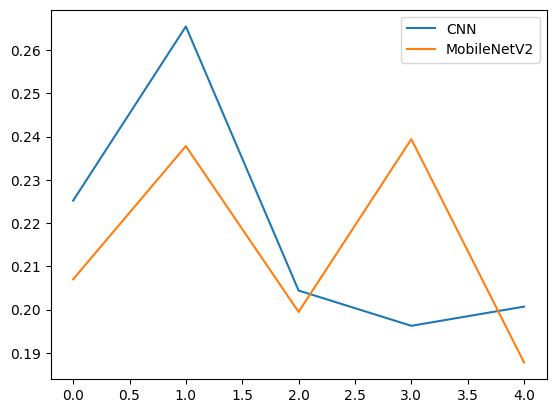

In [18]:
plt.figure()
plt.plot(history_cnn.history['val_loss'], label='CNN')
plt.plot(history_mbv2.history['val_loss'], label='MobileNetV2')
plt.legend()
plt.show()


In [19]:

cnn_model.summary()

mbv2_model.get_layer("mobilenetv2_1.00_224").summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,100,485 (19.46 MB)

 Trainable params: 1,700,161 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
img_tensor = tf.zeros((1, 224, 224, 3), dtype=tf.float32)
img_array = tf.zeros((1, 224, 224, 3), dtype=tf.float32)


In [21]:
_ = cnn_model(tf.zeros((1, 224, 224, 3)))
_ = mbv2_model(img_tensor, training=False)


In [22]:
base_model = mbv2_model.get_layer("mobilenetv2_1.00_224")

last_conv_layer = base_model.get_layer("Conv_1")

grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)


In [23]:
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. Chuẩn bị input
    img_tensor = tf.convert_to_tensor(img_array)
    if len(img_tensor.shape) == 3:
        img_tensor = tf.expand_dims(img_tensor, 0)
    
    # 2. Ghi lại quá trình tính toán (GradientTape)
    with tf.GradientTape() as tape:
        last_conv_layer_output = None
        x = img_tensor
        
        # Lặp qua từng layer của model theo thứ tự (Linear Topology)
        # Cách này chạy tốt cho cả Sequential và Functional (dạng thẳng)
        for layer in model.layers:
            # Bỏ qua layer Input (vì x đã là tensor đầu vào rồi)
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue
            
            # --- XỬ LÝ LỚP CUỐI (Lấy Logits) ---
            # Nếu là layer Dense cuối cùng có Sigmoid/Softmax -> Tự tính toán để bỏ activation
            if layer == model.layers[-1] and hasattr(layer, 'activation') and (layer.activation.__name__ == 'sigmoid' or layer.activation.__name__ == 'softmax'):
                x = tf.matmul(x, layer.kernel) + layer.bias
            else:
                # Các layer khác chạy bình thường
                x = layer(x)
            
            # --- BẮT LẤY OUTPUT CỦA LAYER CẦN SOI ---
            if layer.name == last_conv_layer_name:
                last_conv_layer_output = x
                tape.watch(last_conv_layer_output)
        
        # Lúc này x là Logits (điểm số thô)
        score = x[:, 0] # Lấy giá trị của class đầu tiên

    # 3. Tính Gradients
    if last_conv_layer_output is None:
        raise ValueError(f"Không tìm thấy layer: {last_conv_layer_name}")
        
    grads = tape.gradient(score, last_conv_layer_output)
    
    # 4. Xử lý Heatmap (GAP -> ReLU -> Normalize)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = last_conv_layer_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) 
    
    max_heat = tf.reduce_max(heatmap)
    if max_heat == 0: max_heat = 1e-10
    heatmap /= max_heat
    
    return heatmap.numpy()

In [24]:
import cv2

def display_gradcam(image, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + image
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.figure()
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()


In [112]:
def show_gradcam(img_array, heatmap, title="Grad-CAM"):
    if isinstance(img_array, tf.Tensor):
        img_array = img_array.numpy()

    img = img_array[0]

    if img.max() <= 1.0:
        img = (img * 255).astype("uint8")
    else:
        img = img.astype("uint8")

    # Xử lý heatmap
    heatmap = np.maximum(heatmap, 0)
    max_heat = np.max(heatmap)
    if max_heat == 0:
        max_heat = 1e-8
    heatmap /= max_heat
    
    # Resize heatmap
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Tạo màu
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    
    # Chồng ảnh
    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    # Vẽ hình
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img.astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(title) # Dùng biến title ở đây
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

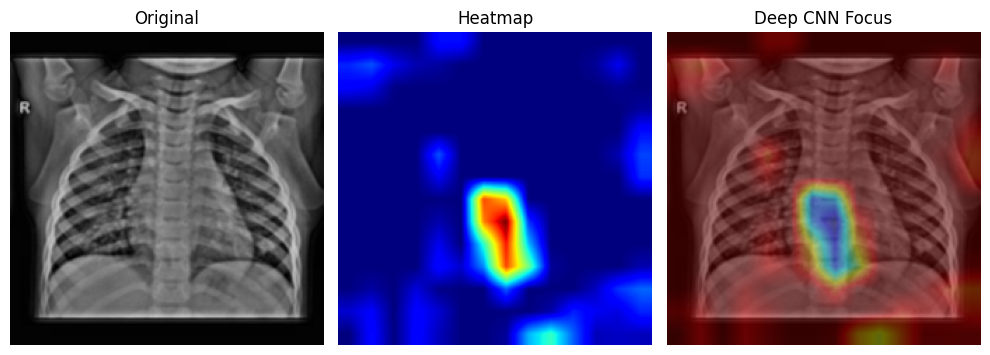

In [119]:
for images, labels in test_ds.take(1):
    sample_img = images[0:1]

# Chạy
hm = get_gradcam_heatmap(sample_img, cnn_model, "conv2d_9") 
show_gradcam(sample_img, hm, title="Deep CNN Focus")

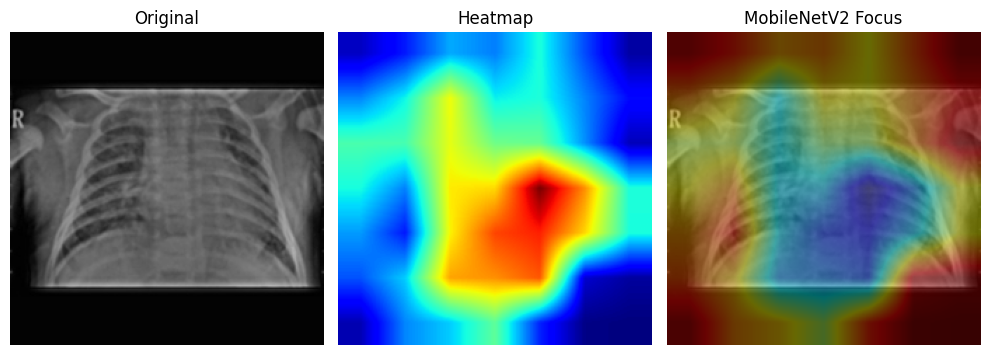

In [114]:
# Lấy ảnh mẫu
for images, labels in test_ds.take(1):
    sample_img = images[0:1]

hm_mb = get_gradcam_heatmap(
    sample_img, 
    mbv2_model, 
    "mobilenetv2_1.00_224"
)

show_gradcam(sample_img, hm_mb, title="MobileNetV2 Focus")

Dang đi tìm ảnh VIÊM PHỔI để so sánh...
✅ Đã tìm thấy ảnh! Bắt đầu so sánh...


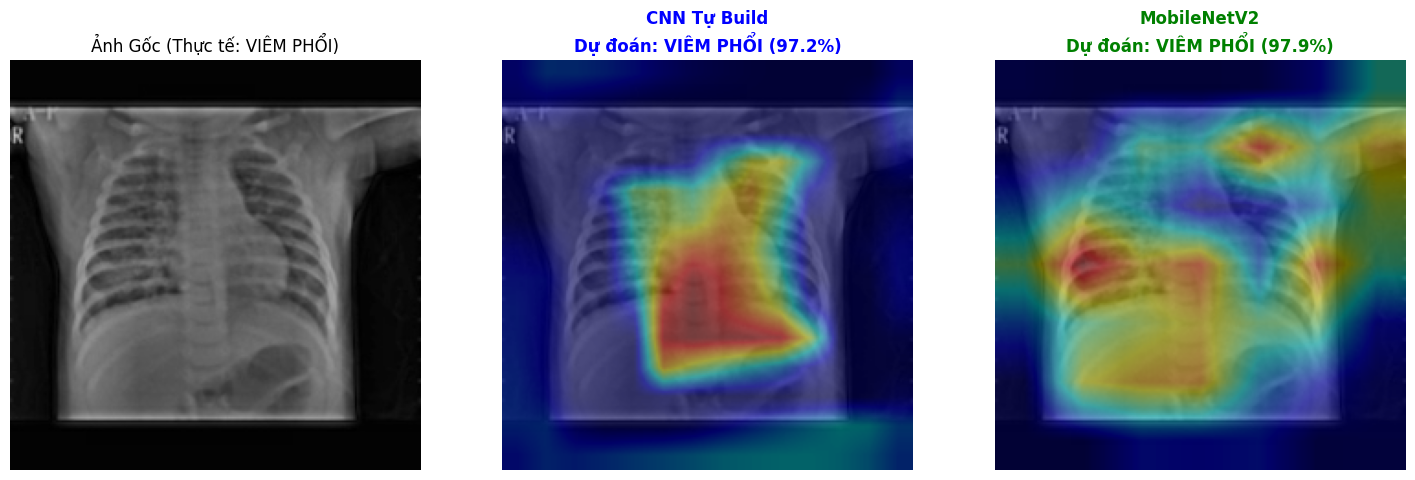

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
#  (1 = PNEUMONIA / Viêm phổi, 0 = NORMAL / Bình thường)
TARGET_LABEL = 1

print(f"Dang đi tìm ảnh {'VIÊM PHỔI' if TARGET_LABEL==1 else 'BÌNH THƯỜNG'} để so sánh...")

found = False
target_img_tensor = None

for images, labels in test_ds:
    lbls = labels.numpy().flatten()
    # Tìm các vị trí có nhãn mong muốn
    indices = np.where(lbls == TARGET_LABEL)[0]
    
    if len(indices) > 0:
        # Lấy ảnh đầu tiên tìm được trong batch này
        idx = indices[0]
        
        # LƯU Ý QUAN TRỌNG: Đây là tấm ảnh gốc duy nhất dùng cho cả 2 model
        target_img_tensor = images[idx:idx+1] 
        found = True
        break # Tìm thấy rồi thì dừng ngay

if found and target_img_tensor is not None:
    print("✅ Đã tìm thấy ảnh! Bắt đầu so sánh...")
    

    # Dự đoán
    pred_cnn = cnn_model.predict(target_img_tensor, verbose=0)[0][0]
    label_cnn = "VIÊM PHỔI" if pred_cnn > 0.5 else "BÌNH THƯỜNG"
    conf_cnn = pred_cnn if label_cnn == "VIÊM PHỔI" else 1 - pred_cnn
    
    # Grad-CAM CNN
    try:
        # Tự tìm layer conv cuối
        last_conv_cnn = next(x.name for x in reversed(cnn_model.layers) if isinstance(x, tf.keras.layers.Conv2D))
        heatmap_cnn = get_gradcam_heatmap(target_img_tensor, cnn_model, last_conv_cnn)
    except:
        heatmap_cnn = np.zeros((224,224)) # Nếu lỗi thì ra màn hình đen
        print("Lỗi GradCAM CNN")

    # Dự đoán
    pred_mb = mbv2_model.predict(target_img_tensor, verbose=0)[0][0]
    label_mb = "VIÊM PHỔI" if pred_mb > 0.5 else "BÌNH THƯỜNG"
    conf_mb = pred_mb if label_mb == "VIÊM PHỔI" else 1 - pred_mb
    
    # Grad-CAM MobileNet
    try:
        heatmap_mb = get_gradcam_heatmap(target_img_tensor, mbv2_model, "mobilenetv2_1.00_224")
    except:
        heatmap_mb = np.zeros((224,224))

    # Chuẩn bị ảnh nền
    original_img = target_img_tensor[0].numpy()
    
    # Hàm trộn màu nhanh
    def apply_heatmap(img, hm):
        hm = cv2.resize(hm, (224, 224))
        hm = np.uint8(255 * hm)
        hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
        return cv2.addWeighted(np.uint8(img*255), 0.6, hm, 0.4, 0)

    overlay_cnn = apply_heatmap(original_img, heatmap_cnn)
    overlay_mb = apply_heatmap(original_img, heatmap_mb)

    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title(f"Ảnh Gốc (Thực tế: {'VIÊM PHỔI' if TARGET_LABEL==1 else 'BÌNH THƯỜNG'})")
    plt.axis('off')
    
    # Cột 2: CNN
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(overlay_cnn, cv2.COLOR_BGR2RGB))
    plt.title(f"CNN Tự Build\nDự đoán: {label_cnn} ({conf_cnn:.1%})", color='blue', fontweight='bold')
    plt.axis('off')
    
    # Cột 3: MobileNet
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(overlay_mb, cv2.COLOR_BGR2RGB))
    plt.title(f"MobileNetV2\nDự đoán: {label_mb} ({conf_mb:.1%})", color='green', fontweight='bold')
    plt.axis('off')
    
    plt.show()

else:
    print("Không tìm thấy ảnh nào thỏa mãn điều kiện.")

Đang thực hiện dự đoán...


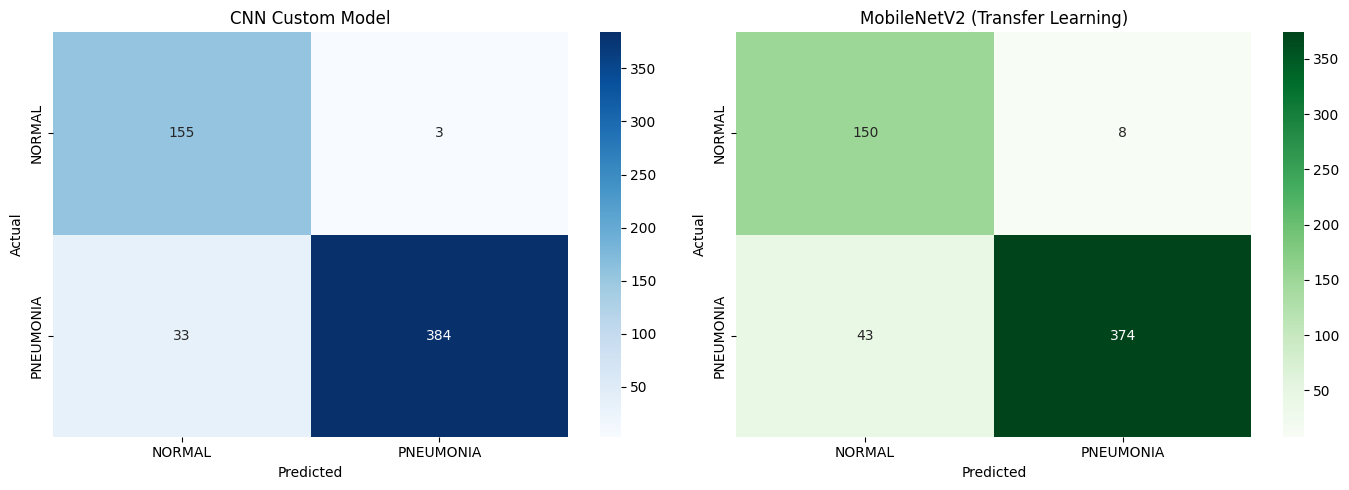


--- Báo cáo chi tiết CNN ---
              precision    recall  f1-score   support

      NORMAL       0.82      0.98      0.90       158
   PNEUMONIA       0.99      0.92      0.96       417

    accuracy                           0.94       575
   macro avg       0.91      0.95      0.93       575
weighted avg       0.95      0.94      0.94       575


--- Báo cáo chi tiết MobileNetV2 ---
              precision    recall  f1-score   support

      NORMAL       0.78      0.95      0.85       158
   PNEUMONIA       0.98      0.90      0.94       417

    accuracy                           0.91       575
   macro avg       0.88      0.92      0.90       575
weighted avg       0.92      0.91      0.91       575



In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred_cnn = []
y_pred_mbv2 = []

THRESHOLD = 0.5 

print("Đang thực hiện dự đoán...")
for images, labels in test_ds:
    # Gom nhãn thật
    y_true.extend(labels.numpy())
    
    # Dự đoán mô hình CNN
    pred_cnn_prob = cnn_model.predict(images, verbose=0)
    y_pred_cnn.extend((pred_cnn_prob > THRESHOLD).astype(int))
    
    # Dự đoán mô hình MobileNetV2
    pred_mbv2_prob = mbv2_model.predict(images, verbose=0)
    y_pred_mbv2.extend((pred_mbv2_prob > THRESHOLD).astype(int))

# Chuyển về dạng numpy array 1 chiều
y_true = np.array(y_true).flatten()
y_pred_cnn = np.array(y_pred_cnn).flatten()
y_pred_mbv2 = np.array(y_pred_mbv2).flatten()

# 2. Hàm vẽ Confusion Matrix so sánh
def plot_side_by_side_cm(y_true, pred_cnn, pred_mbv2, class_names=['NORMAL', 'PNEUMONIA']):
    cm_cnn = confusion_matrix(y_true, pred_cnn)
    cm_mbv2 = confusion_matrix(y_true, pred_mbv2)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot CNN
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title('CNN Custom Model')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # Plot MobileNetV2
    sns.heatmap(cm_mbv2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title('MobileNetV2 (Transfer Learning)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()
    
    # In thêm báo cáo chi tiết
    print("\n--- Báo cáo chi tiết CNN ---")
    print(classification_report(y_true, pred_cnn, target_names=class_names))
    
    print("\n--- Báo cáo chi tiết MobileNetV2 ---")
    print(classification_report(y_true, pred_mbv2, target_names=class_names))

# Gọi hàm vẽ
plot_side_by_side_cm(y_true, y_pred_cnn, y_pred_mbv2)

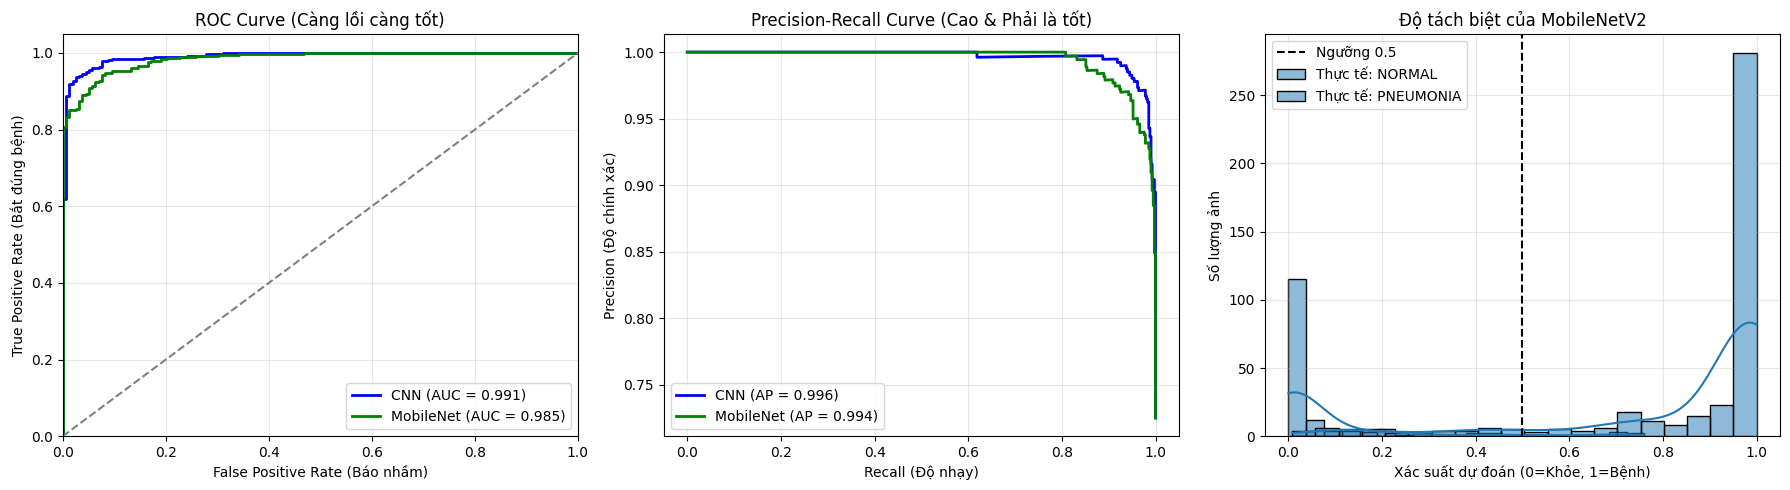

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# --- BƯỚC 1: LẤY DỮ LIỆU DỰ ĐOÁN (NẾU CHƯA CÓ) ---
# Kiểm tra xem đã có biến y_true và prob chưa, nếu chưa thì chạy lại dự đoán
if 'y_true' not in globals() or 'y_pred_prob_cnn' not in globals():
    print("Đang tính toán xác suất dự đoán lại từ đầu (để vẽ biểu đồ)...")
    y_true = []
    y_pred_prob_cnn = []
    y_pred_prob_mbv2 = []
    
    # Lặp qua tập test để lấy nhãn thật và xác suất dự đoán
    for images, labels in test_ds:
        y_true.extend(labels.numpy())
        # Predict trả về xác suất (0.0 đến 1.0)
        y_pred_prob_cnn.extend(cnn_model.predict(images, verbose=0))
        y_pred_prob_mbv2.extend(mbv2_model.predict(images, verbose=0))
        
    y_true = np.array(y_true).flatten()
    y_pred_prob_cnn = np.array(y_pred_prob_cnn).flatten()
    y_pred_prob_mbv2 = np.array(y_pred_prob_mbv2).flatten()
    print("✅ Đã có dữ liệu dự đoán!")

# --- BƯỚC 2: VẼ BIỂU ĐỒ ---
plt.figure(figsize=(18, 5))

# --------------------------
# BIỂU ĐỒ 1: ROC CURVE
# --------------------------
plt.subplot(1, 3, 1)
# Tính toán CNN
fpr_cnn, tpr_cnn, _ = roc_curve(y_true, y_pred_prob_cnn)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
# Tính toán MobileNet
fpr_mb, tpr_mb, _ = roc_curve(y_true, y_pred_prob_mbv2)
roc_auc_mb = auc(fpr_mb, tpr_mb)

plt.plot(fpr_cnn, tpr_cnn, color='blue', lw=2, label=f'CNN (AUC = {roc_auc_cnn:.3f})')
plt.plot(fpr_mb, tpr_mb, color='green', lw=2, label=f'MobileNet (AUC = {roc_auc_mb:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Đường ngẫu nhiên
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Báo nhầm)'); plt.ylabel('True Positive Rate (Bắt đúng bệnh)')
plt.title('ROC Curve (Càng lồi càng tốt)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# --------------------------
# BIỂU ĐỒ 2: PRECISION-RECALL CURVE
# --------------------------
plt.subplot(1, 3, 2)
# Tính toán CNN
prec_cnn, rec_cnn, _ = precision_recall_curve(y_true, y_pred_prob_cnn)
ap_cnn = average_precision_score(y_true, y_pred_prob_cnn)
# Tính toán MobileNet
prec_mb, rec_mb, _ = precision_recall_curve(y_true, y_pred_prob_mbv2)
ap_mb = average_precision_score(y_true, y_pred_prob_mbv2)

plt.plot(rec_cnn, prec_cnn, color='blue', lw=2, label=f'CNN (AP = {ap_cnn:.3f})')
plt.plot(rec_mb, prec_mb, color='green', lw=2, label=f'MobileNet (AP = {ap_mb:.3f})')
plt.xlabel('Recall (Độ nhạy)'); plt.ylabel('Precision (Độ chính xác)')
plt.title('Precision-Recall Curve (Cao & Phải là tốt)')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# --------------------------
# BIỂU ĐỒ 3: PHÂN PHỐI XÁC SUẤT (TÁCH BIỆT CLASS)
# --------------------------
plt.subplot(1, 3, 3)
# Vẽ histogram cho CNN (hoặc chọn MobileNet tùy bạn, ở đây vẽ CNN làm mẫu)
# Tách dữ liệu ra 2 nhóm: Nhóm thực sự bệnh và Nhóm thực sự khỏe
sns.histplot(y_pred_prob_mbv2[y_true==0], color='green', label='Thực tế: NORMAL', kde=True, bins=20, alpha=0.5)
sns.histplot(y_pred_prob_mbv2[y_true==1], color='red', label='Thực tế: PNEUMONIA', kde=True, bins=20, alpha=0.5)

plt.axvline(0.5, color='black', linestyle='--', label='Ngưỡng 0.5')
plt.title('Độ tách biệt của MobileNetV2')
plt.xlabel('Xác suất dự đoán (0=Khỏe, 1=Bệnh)')
plt.ylabel('Số lượng ảnh')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

THRESHOLD = 0.5 


def run_full_demo(image_filename, cnn_model, mbv2_model):
    img_path = f"/kaggle/working/{image_filename}"
    
    try:
        img_tensor = preprocess_image_for_demo(img_path)

        cnn_layer = get_last_conv_name_dynamic(cnn_model)
        pred_prob_cnn = cnn_model.predict(img_tensor, verbose=0)[0][0]
        
        if pred_prob_cnn > THRESHOLD:
            result_cnn = "⚠️ VIÊM PHỔI"
            color_cnn = "red"
            conf_cnn = pred_prob_cnn
        else:
            result_cnn = "✅ BÌNH THƯỜNG"
            color_cnn = "green"
            conf_cnn = 1 - pred_prob_cnn
            
        mbv2_layer = "mobilenetv2_1.00_224"
        pred_prob_mbv2 = mbv2_model.predict(img_tensor, verbose=0)[0][0]
        
        if pred_prob_mbv2 > THRESHOLD:
            result_mbv2 = "⚠️ VIÊM PHỔI"
            color_mbv2 = "red"
            conf_mbv2 = pred_prob_mbv2
        else:
            result_mbv2 = "✅ BÌNH THƯỜNG"
            color_mbv2 = "green"
            conf_mbv2 = 1 - pred_prob_mbv2

        print("\n" + "="*40)
        print(f"📄 KẾT QUẢ PHÂN TÍCH CHO: {image_filename}")
        print("="*40)
        print(f"1️  CNN Model dự đoán:      {result_cnn} (Độ tin cậy: {conf_cnn:.1%})")
        print(f"2️  MobileNetV2 dự đoán:    {result_mbv2} (Độ tin cậy: {conf_mbv2:.1%})")
        print("="*40 + "\n")

      
        heatmap_cnn = get_gradcam_heatmap(img_tensor, cnn_model, cnn_layer)
        overlay_cnn_img = overlay_heatmap(img_path, heatmap_cnn)
        
        heatmap_mbv2 = get_gradcam_heatmap(img_tensor, mbv2_model, mbv2_layer)
        overlay_mbv2_img = overlay_heatmap(img_path, heatmap_mbv2)

        plt.figure(figsize=(16, 6))

        orig = cv2.imread(img_path)
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title("Ảnh X-Quang Gốc")
        plt.axis('off')
        
        # CNN Result
        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(overlay_cnn_img, cv2.COLOR_BGR2RGB))
        plt.title(f"CNN: {result_cnn}\n({conf_cnn:.1%})", color=color_cnn, fontweight='bold')
        plt.axis('off')
        
        # MobileNet Result
        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(overlay_mbv2_img, cv2.COLOR_BGR2RGB))
        plt.title(f"MobileNet: {result_mbv2}\n({conf_mbv2:.1%})", color=color_mbv2, fontweight='bold')
        plt.axis('off')
        
        plt.show()
        
    except Exception as e:
        print(f" Lỗi khi chạy demo: {e}")


def on_predict_clicked(b):
    with out:
        clear_output()
        if not uploader.value:
            print("⚠️ Bạn chưa chọn ảnh nào cả! Hãy bấm nút Upload trước.")
            return  
        try:
            # Code lấy file (giữ nguyên như trước)
            if isinstance(uploader.value, dict):
                key = list(uploader.value.keys())[0]
                content = uploader.value[key]['content']
                filename = uploader.value[key]['metadata']['name']
            else:
                uploaded_file = uploader.value[0]
                content = uploaded_file.content
                filename = uploaded_file.name
                if isinstance(content, memoryview): content = content.tobytes()
            
            save_path = f"/kaggle/working/{filename}"
            with open(save_path, "wb") as f:
                f.write(content)
                
            # Gọi hàm run_full_demo mới
            run_full_demo(filename, cnn_model, mbv2_model)
                
        except Exception as e:
            print(f" Có lỗi xảy ra: {e}")
predict_btn.on_click(on_predict_clicked)



✅ Đã cập nhật demo! Bây giờ nó sẽ báo rõ là 'VIÊM PHỔI' hay 'BÌNH THƯỜNG'.


In [41]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import os


print("=== HỆ THỐNG CHẨN ĐOÁN VIÊM PHỔI TỰ ĐỘNG ===")
print("Hãy bấm nút 'Upload' bên dưới để chọn ảnh X-Quang từ máy tính của bạn.")

# 1. Tạo nút Upload
uploader = widgets.FileUpload(
    accept='image/*',  # Chỉ chấp nhận file ảnh
    multiple=False     # Chỉ chọn 1 ảnh mỗi lần
)

# 2. Tạo nút Chạy dự đoán
predict_btn = widgets.Button(
    description="Phân tích ngay",
    button_style='primary', 
    icon='stethoscope' 

out = widgets.Output()

def on_predict_clicked(b):
    with out:
        clear_output() # Xóa kết quả cũ
        if not uploader.value:
            print("⚠️ Bạn chưa chọn ảnh nào cả! Hãy bấm nút Upload trước.")
            return
            
        try:
            if isinstance(uploader.value, dict): # Bản cũ
                key = list(uploader.value.keys())[0]
                content = uploader.value[key]['content']
                filename = uploader.value[key]['metadata']['name']
            else: # Bản mới (Kaggle thường dùng bản này)
                uploaded_file = uploader.value[0]
                content = uploaded_file.content
                filename = uploaded_file.name
                if isinstance(content, memoryview):
                    content = content.tobytes()
            
            # Lưu file tạm xuống ổ cứng Kaggle
            save_path = f"/kaggle/working/{filename}"
            with open(save_path, "wb") as f:
                f.write(content)
                
            print(f"✅ Đã nhận ảnh: {filename}")
            print("⏳ Đang phân tích...")
            
            if 'run_full_demo' in globals():
                run_full_demo(filename, cnn_model, mbv2_model)
            else:
                print(" Lỗi: Bạn chưa chạy cell khai báo hàm 'run_full_demo' ở trên.")
                
        except Exception as e:
            print(f"Có lỗi xảy ra khi đọc ảnh: {e}")

# Gắn sự kiện vào nút bấm
predict_btn.on_click(on_predict_clicked)

# Hiển thị giao diện
display(uploader)
display(predict_btn)
display(out)

=== HỆ THỐNG CHẨN ĐOÁN VIÊM PHỔI TỰ ĐỘNG ===
Hãy bấm nút 'Upload' bên dưới để chọn ảnh X-Quang từ máy tính của bạn.


FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='primary', description='Phân tích ngay', icon='stethoscope', style=ButtonStyle())

Output()

In [64]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os


def get_occlusion_heatmap(model, img_tensor, label_index, patch_size=32, stride=8):
    # Lấy xác suất gốc
    original_prob = model.predict(img_tensor, verbose=0)[0][label_index]
    
    # Xử lý input (Tensor -> Numpy)
    if hasattr(img_tensor, 'numpy'):
        img_array = img_tensor[0].numpy()
    else:
        img_array = img_tensor[0]
        
    height, width, _ = img_array.shape
    heatmap = np.zeros((height, width))
    
    masked_images = []
    coords = []
    
    # Tạo hàng loạt ảnh bị che (Batching)
    for h in range(0, height - patch_size + 1, stride):
        for w in range(0, width - patch_size + 1, stride):
            masked_img = img_array.copy()
            masked_img[h:h+patch_size, w:w+patch_size, :] = 0
            masked_images.append(masked_img)
            coords.append((h, w))
            
    # Dự đoán theo batch (Nhanh hơn loop)
    # Chia nhỏ batch nếu quá nhiều ảnh con (tránh tràn RAM)
    BATCH_SIZE_INFER = 32
    masked_images = np.array(masked_images)
    predictions = model.predict(masked_images, batch_size=BATCH_SIZE_INFER, verbose=0)
    
    # Tính độ sụt giảm
    for i, (h, w) in enumerate(coords):
        prob = predictions[i][label_index]
        diff = original_prob - prob 
        heatmap[h:h+patch_size, w:w+patch_size] += diff

    # Chuẩn hóa
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
        
    return heatmap


def run_occlusion_demo(filename, model):
    img_path = f"/kaggle/working/{filename}"
    
    # Nạp ảnh chuẩn hóa về [0, 1]
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_tensor = np.expand_dims(img_array / 255.0, axis=0)
    
    # Dự đoán sơ bộ để biết class nào (0 hay 1)
    preds = model.predict(img_tensor, verbose=0)
    pred_prob = preds[0][0]
    
    if pred_prob > 0.5:
        target_class = 0 # Node 0 (nhưng giá trị cao) -> Logic Sigmoid 1 output
        label_text = f"VIÊM PHỔI ({pred_prob:.1%})"
    else:
        target_class = 0 
        label_text = f"BÌNH THƯỜNG ({1-pred_prob:.1%})"
        
    print(f" Đang phân tích ảnh '{filename}'...")
    print(f"   Dự đoán ban đầu: {label_text}")
    print(" Đang chạy thuật toán che khuất (Occlusion)... (Chờ khoảng 15-30 giây)")
    
    # Chạy Occlusion (Lưu ý: Sigmoid 1 output thì luôn tính trên node 0)
    heatmap = get_occlusion_heatmap(model, img_tensor, 0, patch_size=30, stride=8)
    
    # Hiển thị
    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv, (224, 224))
    
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_cv, 0.6, heatmap_color, 0.4, 0)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.title(f"Ảnh Gốc\n{label_text}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Vùng Quan Trọng Nhất (Đỏ)\n(Occlusion Sensitivity)")
    plt.axis('off')
    plt.show()


upload_btn_occ = widgets.FileUpload(accept='image/*', multiple=False)
run_btn_occ = widgets.Button(description="Chạy Occlusion", button_style='warning', icon='eye')
out_occ = widgets.Output()

def on_run_occ_clicked(b):
    with out_occ:
        clear_output()
        if not upload_btn_occ.value:
            print(" Bạn chưa chọn ảnh! Hãy upload trước.")
            return
            
        # Lưu file
        if isinstance(upload_btn_occ.value, dict): # ipywidgets cũ
            key = list(upload_btn_occ.value.keys())[0]
            content = upload_btn_occ.value[key]['content']
            fname = upload_btn_occ.value[key]['metadata']['name']
        else: # ipywidgets mới
            file_info = upload_btn_occ.value[0]
            content = file_info.content
            fname = file_info.name
            if isinstance(content, memoryview): content = content.tobytes()
            
        save_path = f"/kaggle/working/{fname}"
        with open(save_path, "wb") as f:
            f.write(content)
            
        # Gọi hàm xử lý (Dùng MobileNetV2 vì nó nhanh và tốt hơn)
        if 'mbv2_model' in globals():
            run_occlusion_demo(fname, mbv2_model)
        else:
            print(" Lỗi: Không tìm thấy model 'mbv2_model'.")

run_btn_occ.on_click(on_run_occ_clicked)

print(" CÔNG CỤ SOI 'ĐỘ NHẠY CHE KHUẤT' (OCCLUSION) ")
display(upload_btn_occ)
display(run_btn_occ)
display(out_occ)

=== CÔNG CỤ SOI 'ĐỘ NHẠY CHE KHUẤT' (OCCLUSION) ===


FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='warning', description='Chạy Occlusion', icon='eye', style=ButtonStyle())

Output()

In [57]:
import os
if 'cnn_model' in globals():
    cnn_save_path = "cnn_pneumonia_model.keras"
    cnn_model.save(cnn_save_path)
    print(f"Đã lưu xong: {cnn_save_path}")
else:
    print("Lỗi: Không tìm thấy biến 'cnn_model'. Có thể bạn đã reset kernel?")

if 'mbv2_model' in globals():
    mbv2_save_path = "mobilenetv2_pneumonia_model.keras"
    mbv2_model.save(mbv2_save_path)
    print(f" Đã lưu xong: {mbv2_save_path}")
else:
    print(" Lỗi: Không tìm thấy biến 'mbv2_model'.")

# 3. Kiểm tra file đã tồn tại chưa
print("\nDanh sách file trong thư mục hiện tại:")
print(os.listdir("/kaggle/working/"))

✅ Đã lưu xong: cnn_pneumonia_model.keras
✅ Đã lưu xong: mobilenetv2_pneumonia_model.keras

Danh sách file trong thư mục hiện tại:
['phổi khỏe.png', 'mobilenetv2_pneumonia_model.keras', '.virtual_documents', 'cnn_pneumonia_model.keras', 'xrayp.jpg']
